# Catálogo de paneles

Descripción breve de las cuatro tablas que produce el pipeline y de los
datos que contiene cada una.

Para el **qué y por qué** de cada fuente, ver
[`METODOLOGIA.md`](METODOLOGIA.md) (sección 1.2, *Para qué sirve cada
fuente*). Para el **cómo** se generan, ver
[`GUIA_CODIGO.md`](GUIA_CODIGO.md).

Las cifras de este cuaderno se leen de los archivos, así que se
actualizan solas al volver a ejecutarlo.

In [1]:
import warnings

import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

from config_local import DIR_PANEL


def cargar(nombre):
    """Lee un panel, prefiriendo Parquet y cayendo al CSV.

    En el CSV hay que declarar cod_dane como texto: los codigos DANE
    llevan cero a la izquierda en Antioquia (05001) y Atlantico (08001),
    y si pandas los infiere como entero ese cero desaparece.
    """
    try:
        return pd.read_parquet(DIR_PANEL / f"{nombre}.parquet")
    except Exception:
        return pd.read_csv(DIR_PANEL / f"{nombre}.csv",
                           dtype={"cod_dane": "string"})


gfw    = cargar("panel_deforestacion_colombia")
hansen = cargar("panel_hansen")
ideam  = cargar("panel_ideam")
dtd    = cargar("panel_dtd")

print("Paneles cargados.")

Paneles cargados.


## Resumen

Los cuatro paneles cubren la **misma grilla de 5 km** y comparten el mismo
`bosque_base_ha`, el mismo cruce municipal y el mismo indexado de píxel a
celda. Esa base común es lo que permite compararlos entre sí.

Miden conceptos distintos, así que **sus cifras nunca se suman**.

In [2]:
resumen = pd.DataFrame([
    {"panel": "panel_deforestacion_colombia", "fuente": "GFW",
     "mide": "Disturbio de la vegetación", "unidad": "hectáreas",
     "grano": "celda x mes"},
    {"panel": "panel_hansen", "fuente": "Hansen GFC",
     "mide": "Pérdida de cobertura arbórea", "unidad": "hectáreas",
     "grano": "celda x año"},
    {"panel": "panel_ideam", "fuente": "IDEAM / SMByC",
     "mide": "Deforestación de bosque natural", "unidad": "hectáreas",
     "grano": "celda x periodo"},
    {"panel": "panel_dtd", "fuente": "IDEAM / SMByC",
     "mide": "Detecciones de alerta temprana", "unidad": "conteo de puntos",
     "grano": "celda x trimestre"},
]).set_index("panel")

tablas = {"panel_deforestacion_colombia": gfw, "panel_hansen": hansen,
          "panel_ideam": ideam, "panel_dtd": dtd}
resumen["filas"] = [f"{len(tablas[p]):,}" for p in resumen.index]
resumen["columnas"] = [tablas[p].shape[1] for p in resumen.index]
resumen["celdas"] = [f"{tablas[p].cell_id.nunique():,}" for p in resumen.index]
resumen["municipios"] = [tablas[p].cod_dane.nunique() for p in resumen.index]
resumen

,fuente,mide,unidad,grano,filas,columnas,celdas,municipios
panel,,,,,,,,
panel_deforestacion_colombia,GFW,Disturbio de la vegetación,hectáreas,celda x mes,"3,524,664",19,"44,616",1114
panel_hansen,Hansen GFC,Pérdida de cobertura arbórea,hectáreas,celda x año,"267,696",9,"44,616",1114
panel_ideam,IDEAM / SMByC,Deforestación de bosque natural,hectáreas,celda x periodo,"223,080",15,"44,616",1114
panel_dtd,IDEAM / SMByC,Detecciones de alerta temprana,conteo de puntos,celda x trimestre,"1,115,400",14,"44,616",1114


In [3]:
# Verificacion de que la base comun es realmente comun.
celdas = {n: set(t.cell_id) for n, t in tablas.items()}
base = next(iter(celdas.values()))
bosque = {n: t.groupby("cell_id").bosque_base_ha.first() for n, t in tablas.items()}
ref = next(iter(bosque.values()))

print("mismas celdas en los cuatro :", all(c == base for c in celdas.values()))
print("diferencia max en bosque_base_ha:",
      max((v - ref).abs().max() for v in bosque.values()))
print(f"bosque base total           : {ref.sum():,.0f} ha")

mismas celdas en los cuatro : True
diferencia max en bosque_base_ha: 0.0
bosque base total           : 77,713,177 ha


---

## 1. `panel_deforestacion_colombia` — alertas de GFW

**Qué contiene.** Hectáreas con alerta de disturbio de la vegetación por
celda y mes, a partir del producto integrado `gfw_integrated_alerts`
(GLAD-L, GLAD-S2 y RADD), filtrado a confianza alta y muy alta.

**Para qué sirve.** Responde **cuándo** está ocurriendo el fenómeno. Es el
de mayor resolución temporal y el insumo previsto para el modelo.

**Panel balanceado**: toda celda tiene una fila en todo periodo, de modo
que `filas = celdas × periodos` exactamente.

In [4]:
print(f"periodos      : {gfw.periodo.min():%Y-%m} a {gfw.periodo.max():%Y-%m} "
      f"({gfw.periodo.nunique()} meses)")
print(f"balanceado    : {len(gfw) == gfw.cell_id.nunique() * gfw.periodo.nunique()}")
print(f"area con alerta: {gfw.area_def_ha.sum():,.0f} ha")
print(f"celda-mes con evento: {100 * gfw.evento.mean():.2f} %")
print()
print("Columnas:")
for i, c in enumerate(gfw.columns, 1):
    print(f"  {i:2d}. {c:<22} {gfw[c].dtype}")

periodos      : 2020-01 a 2026-07 (79 meses)
balanceado    : True
area con alerta: 1,088,768 ha
celda-mes con evento: 28.17 %

Columnas:
   1. cell_id                object
   2. periodo                datetime64[ns]
   3. area_def_ha            float64
   4. lon                    float64
   5. lat                    float64
   6. bosque_base_ha         float64
   7. departamento           object
   8. def_acum_ha            float64
   9. bosque_remanente_ha    float64
  10. tasa_def               float64
  11. evento                 int8
  12. lag_1_ha               float64
  13. lag_2_ha               float64
  14. lag_3_ha               float64
  15. media_movil_3          float64
  16. anio                   int32
  17. mes                    int32
  18. cod_dane               object
  19. municipio              object


In [5]:
gfw[gfw.evento == 1].head(3)

,cell_id,periodo,area_def_ha,lon,lat,bosque_base_ha,departamento,def_acum_ha,bosque_remanente_ha,tasa_def,evento,lag_1_ha,lag_2_ha,lag_3_ha,media_movil_3,anio,mes,cod_dane,municipio
0,-668855_13972,2020-01-01,1.10757,-66.885465,1.397242,1802.5625,Guainía,1.10757,1802.56250,0.000614,1,NaN,NaN,NaN,NaN,2020,1,94885,La Guadalupe
1,-668855_13972,2020-02-01,1.32906,-66.885465,1.397242,1802.5625,Guainía,2.43663,1801.45493,0.000738,1,1.10757,NaN,NaN,NaN,2020,2,94885,La Guadalupe
2,-668855_13972,2020-03-01,0.04924,-66.885465,1.397242,1802.5625,Guainía,2.48587,1800.12587,0.000027,1,1.32906,1.10757,NaN,NaN,2020,3,94885,La Guadalupe


---

## 2. `panel_hansen` — pérdida de cobertura arbórea

**Qué contiene.** Hectáreas que perdieron cobertura arbórea por celda y
año, desde la capa `lossyear` de Hansen Global Forest Change.

**Para qué sirve.** Responde **cómo se compara Colombia con otros
países**: Hansen aplica el mismo algoritmo en todo el planeta. El mismo
producto aporta además la línea base `bosque_base_ha` que usan los cuatro
paneles.

**Ojo con el concepto**: la pérdida de cobertura incluye cosecha de
plantación forestal, incendio y daño natural, así que su cifra es mayor
que la deforestación oficial.

In [6]:
print("Pérdida de cobertura por año (ha):")
print(hansen.groupby("anio").perdida_ha.sum().apply(lambda x: f"{x:,.0f}").to_string())
print()
print("Columnas:")
for i, c in enumerate(hansen.columns, 1):
    print(f"  {i:2d}. {c:<22} {hansen[c].dtype}")

Pérdida de cobertura por año (ha):
anio
2020    324,608
2021    265,200
2022    266,168
2023    197,246
2024    213,785
2025    186,697

Columnas:
   1. cell_id                object
   2. anio                   int64
   3. perdida_ha             float64
   4. lon                    float64
   5. lat                    float64
   6. departamento           object
   7. bosque_base_ha         float64
   8. cod_dane               object
   9. municipio              object


---

## 3. `panel_ideam` — deforestación oficial

**Qué contiene.** Las cinco clases de las capas de cambio del SMByC por
celda y periodo, en hectáreas. La clase de interés es `def_ha`
(deforestación); las demás sirven de contexto y control de calidad.

**Para qué sirve.** Responde **cuánto**, con la cifra oficial de Colombia
y la definición nacional de bosque.

**Dos advertencias sobre esta tabla:**

- `periodo` designa una **transición** entre dos composiciones anuales de
  imágenes, y su cifra corresponde al **año final**: `2022-2023` produce
  el dato oficial de 2023.
- El denominador correcto para sus tasas es **`bosque_ideam_ha`** (bosque
  natural), no `bosque_base_ha` (Hansen, que incluye plantaciones).

In [7]:
col = ["def_ha", "bosque_estable_ha", "regeneracion_ha", "sin_info_ha"]
por_periodo = ideam.groupby("periodo")[col].sum()

# Cifra oficial publicada por el IDEAM, para contrastar.
OFICIAL = {"2020-2021": 174_103, "2021-2022": 123_517,
           "2022-2023": 79_256, "2023-2024": 113_608,
           "2024-2025": 119_483}
por_periodo["oficial_ha"] = pd.Series(OFICIAL)
por_periodo["recuperado_%"] = (100 * por_periodo.def_ha / por_periodo.oficial_ha).round(2)

# Las hectareas se redondean a entero; el porcentaje conserva decimales
# porque la cercania al 100 % es justamente lo que valida la agregacion.
por_periodo.astype({c: "int64" for c in col + ["oficial_ha"]}, errors="ignore")

,def_ha,bosque_estable_ha,regeneracion_ha,sin_info_ha,oficial_ha,recuperado_%
periodo,,,,,,
2020-2021,173662,59120882,30,116394,174103,99.75
2021-2022,123204,58879438,185,147406,123517,99.75
2022-2023,78982,58854550,57,561,79256,99.65
2023-2024,113422,58745672,324,376,113608,99.84
2024-2025,119282,58576834,1069,250,119483,99.83


In [8]:
print("Los dos denominadores, a escala nacional:")
b = ideam[ideam.periodo == ideam.periodo.min()]
print(f"  bosque_base_ha  (Hansen, dosel >= 30 %) : {b.bosque_base_ha.sum():>14,.0f} ha")
print(f"  bosque_ideam_ha (bosque natural, IDEAM) : {b.bosque_ideam_ha.sum():>14,.0f} ha")
print()
print("Columnas:")
for i, c in enumerate(ideam.columns, 1):
    print(f"  {i:2d}. {c:<22} {ideam[c].dtype}")

Los dos denominadores, a escala nacional:
  bosque_base_ha  (Hansen, dosel >= 30 %) :     77,713,177 ha
  bosque_ideam_ha (bosque natural, IDEAM) :     59,294,546 ha

Columnas:
   1. cell_id                object
   2. periodo                object
   3. bosque_estable_ha      float64
   4. def_ha                 float64
   5. sin_info_ha            float64
   6. regeneracion_ha        float64
   7. no_bosque_ha           float64
   8. bosque_ideam_ha        float64
   9. bosque_ideam_fin_ha    float64
  10. lon                    float64
  11. lat                    float64
  12. departamento           object
  13. bosque_base_ha         float64
  14. cod_dane               object
  15. municipio              object


---

## 4. `panel_dtd` — alertas tempranas oficiales

**Qué contiene.** Número de puntos de alerta que el IDEAM publicó por
celda y trimestre, más cuántos de ellos caen en un área protegida del
SINAP.

**Para qué sirve.** Responde **dónde**, con respaldo de la autoridad
ambiental. Es el único producto oficial de cadencia sub-anual disponible
para Colombia.

**La unidad es el conteo, no la hectárea.** Los datos son puntos sin
superficie asociada: marcan un sitio donde se detectó un cambio
compatible con deforestación, sin cuantificar su extensión.

**Ningún agregado de esta tabla sirve como serie temporal.** El criterio
de detección cambió a lo largo de la serie, así que los conteos por año
se mueven en sentido contrario a la deforestación real. La tabla sirve
**dentro** de cada trimestre, para comparar unos lugares con otros.

In [9]:
print(f"trimestres: {dtd.trimestre_txt.min()} a {dtd.trimestre_txt.max()} "
      f"({dtd.trimestre_txt.nunique()})")
print(f"balanceado: {len(dtd) == dtd.cell_id.nunique() * dtd.trimestre_txt.nunique()}")
print()
print("Detecciones por año:")
print(dtd.groupby("anio").n_alertas.sum().apply(lambda x: f"{x:,}").to_string())
print()

# sinap_disponible marca los trimestres en que el IDEAM informa el campo:
# un vacio de informacion y una ausencia de alertas son cosas distintas.
con = dtd[dtd.sinap_disponible]
print(f"En areas protegidas del SINAP: {int(con.n_alertas_sinap.sum()):,} de "
      f"{con.n_alertas.sum():,} ({100 * con.n_alertas_sinap.sum() / con.n_alertas.sum():.1f} %), "
      f"en {con.trimestre_txt.nunique()} de {dtd.trimestre_txt.nunique()} trimestres")
print()
print("Columnas:")
for i, c in enumerate(dtd.columns, 1):
    print(f"  {i:2d}. {c:<22} {dtd[c].dtype}")

trimestres: 2020-T1 a 2026-T1 (25)
balanceado: True

Detecciones por año:
anio
2020    21,895
2021    15,065
2022    27,579
2023    31,923
2024    45,754
2025    51,072
2026    28,990

En areas protegidas del SINAP: 19,645 de 177,215 (11.1 %), en 18 de 25 trimestres

Columnas:
   1. cell_id                object
   2. periodo                datetime64[ns]
   3. trimestre_txt          object
   4. anio                   int64
   5. trimestre              int64
   6. n_alertas              int64
   7. n_alertas_sinap        float64
   8. sinap_disponible       bool
   9. lon                    float64
  10. lat                    float64
  11. departamento           object
  12. bosque_base_ha         float64
  13. cod_dane               object
  14. municipio              object


---

## Las tres fuentes en hectáreas, lado a lado

Las tres primeras tablas miden superficie y son comparables en magnitud.
Las razones frente a la cifra oficial **varían año a año**, así que
convertir una fuente en otra exige un factor específico para cada año.

In [10]:
anual = pd.DataFrame({
    "GFW_ha": gfw.groupby("anio").area_def_ha.sum(),
    "Hansen_ha": hansen.groupby("anio").perdida_ha.sum(),
    "IDEAM_ha": (ideam.assign(anio=ideam.periodo.str[-4:].astype(int))
                      .groupby("anio").def_ha.sum()),
})
anual["oficial_ha"] = pd.Series(
    {2021: 174_103, 2022: 123_517, 2023: 79_256,
     2024: 113_608, 2025: 119_483})
anual["Hansen/IDEAM"] = (anual.Hansen_ha / anual.IDEAM_ha).round(2)
anual["GFW/IDEAM"] = (anual.GFW_ha / anual.IDEAM_ha).round(2)

for c in ["GFW_ha", "Hansen_ha", "IDEAM_ha", "oficial_ha"]:
    anual[c] = anual[c].round(0)
anual

,GFW_ha,Hansen_ha,IDEAM_ha,oficial_ha,Hansen/IDEAM,GFW/IDEAM
anio,,,,,,
2020,219394.0,324608.0,NaN,NaN,NaN,NaN
2021,194710.0,265200.0,173663.0,174103.0,1.53,1.12
2022,170286.0,266168.0,123204.0,123517.0,2.16,1.38
2023,123973.0,197246.0,78982.0,79256.0,2.50,1.57
2024,155220.0,213785.0,113423.0,113608.0,1.88,1.37
2025,144577.0,186697.0,119282.0,119483.0,1.57,1.21
2026,80608.0,NaN,NaN,NaN,NaN,NaN


---

## Cómo se ve cada fuente en el mapa

Un mapa con una capa por fuente, para comparar su patrón espacial sobre
todo el país.

El mapa base es OpenStreetMap, desaturado con el mismo filtro CSS que usa
`mapa_folium.py` para que los datos resalten sobre un fondo gris.

In [11]:
import folium
from folium.plugins import Fullscreen, HeatMap

from mapa_folium import CENTRO_COLOMBIA, TILES_DEFECTO, atenuar_mapa_base

# Cada panel se colapsa a UNA fila por celda, sumando toda su ventana.
# Asi las cuatro fuentes quedan sobre la misma geometria y se pueden
# superponer como capas del mismo mapa.
por_celda = {
    "GFW — disturbio (ha)":        gfw.groupby("cell_id").area_def_ha.sum(),
    "Hansen — pérdida (ha)":       hansen.groupby("cell_id").perdida_ha.sum(),
    "IDEAM — deforestación (ha)":  ideam.groupby("cell_id").def_ha.sum(),
    "DTD — detecciones (conteo)":  dtd.groupby("cell_id").n_alertas.sum(),
}

# Coordenadas de cada celda, iguales en los cuatro paneles.
coords = gfw.groupby("cell_id")[["lat", "lon"]].first()

for nombre, serie in por_celda.items():
    activas = (serie > 0).sum()
    print(f"{nombre:<30} {activas:>6,} celdas con dato "
          f"({100 * activas / len(serie):>4.1f} %)")

GFW — disturbio (ha)           36,396 celdas con dato (81.6 %)
Hansen — pérdida (ha)          30,225 celdas con dato (67.7 %)
IDEAM — deforestación (ha)     18,385 celdas con dato (41.2 %)
DTD — detecciones (conteo)     12,330 celdas con dato (27.6 %)


### Una capa por fuente

Cada capa es un mapa de calor con el peso **normalizado dentro de su
propia fuente**. Eso es deliberado: las unidades no son comparables
(hectáreas frente a conteos), pero el **patrón espacial** sí, y es lo que
interesa contrastar aquí. Enciende y apaga capas para ver si los focos
coinciden.

Para no producir un archivo de decenas de MB, cada capa se limita a sus
celdas de mayor actividad. El patrón nacional se conserva; para el detalle
completo está `mapa_folium.py`.

> **Si el mapa no se ve aquí abajo** y en su lugar aparece *"Make this
> Notebook Trusted to load map"*: folium incrusta el mapa en un
> `<iframe srcdoc=...>` que Jupyter bloquea mientras el cuaderno no esté
> marcado como confiable, y que GitHub no renderiza nunca. La celda
> guarda además el mapa en `datos/panel/mapa_fuentes.html`, que se abre
> con doble clic en cualquier navegador.

In [12]:
TOPE = 4000   # celdas por capa: suficiente para el patron, liviano de abrir

# Un color por fuente, para distinguirlas al alternar capas.
GRADIENTES = {
    "GFW — disturbio (ha)":       {0.3: "#FBE3CE", 0.6: "#E2905A", 1.0: "#7A3319"},
    "Hansen — pérdida (ha)":      {0.3: "#FDE68A", 0.6: "#D97706", 1.0: "#78350F"},
    "IDEAM — deforestación (ha)": {0.3: "#FECDD3", 0.6: "#E11D48", 1.0: "#701A29"},
    "DTD — detecciones (conteo)": {0.3: "#C7D2FE", 0.6: "#4F46E5", 1.0: "#26216B"},
}

mapa = folium.Map(location=CENTRO_COLOMBIA, zoom_start=5,
                  tiles=TILES_DEFECTO, control_scale=True, prefer_canvas=True)
atenuar_mapa_base(mapa)

for i, (nombre, serie) in enumerate(por_celda.items()):
    top = serie[serie > 0].nlargest(TOPE)
    xy = coords.loc[top.index]
    # Peso relativo al maximo de ESTA fuente, no al de todas.
    peso = (top / top.max()).round(3)
    HeatMap(
        list(zip(xy.lat.round(4), xy.lon.round(4), peso)),
        name=nombre, radius=10, blur=15, max_zoom=9, min_opacity=.3,
        gradient=GRADIENTES[nombre],
        show=(i == 0),          # solo la primera encendida al abrir
    ).add_to(mapa)

# Bosque base como contexto: donde habia bosque para empezar.
bb = ideam.groupby("cell_id").bosque_base_ha.first()
top_bb = bb.nlargest(TOPE)
xy = coords.loc[top_bb.index]
HeatMap(list(zip(xy.lat.round(4), xy.lon.round(4),
                 (top_bb / top_bb.max()).round(3))),
        name="Bosque base (contexto)", radius=9, blur=14, max_zoom=9,
        min_opacity=.15, show=False,
        gradient={0.2: "#2A3327", 0.6: "#4C5A4E", 1.0: "#1E6B45"}).add_to(mapa)

folium.LayerControl(collapsed=False).add_to(mapa)
Fullscreen(position="topleft").add_to(mapa)

# Ademas de mostrarlo aqui, se guarda como HTML suelto. Folium incrusta
# el mapa en un <iframe srcdoc=...> que Jupyter bloquea mientras el
# cuaderno no este marcado como confiable, y que GitHub no renderiza
# nunca. El archivo suelto se abre con doble click en cualquier
# navegador, sin ese problema.
SALIDA_MAPA = DIR_PANEL / "mapa_fuentes.html"
mapa.save(str(SALIDA_MAPA))
print(f"Mapa guardado en: {SALIDA_MAPA}")
print("(si abajo dice 'Make this Notebook Trusted', abra ese archivo)")

mapa

Mapa guardado en: C:\Users\busta\trabajo_de_grado_ofr\datos\panel\mapa_fuentes.html
(si abajo dice 'Make this Notebook Trusted', abra ese archivo)


Los focos de las tres fuentes en hectáreas se concentran en el mismo
arco amazónico —Caquetá, Meta, Guaviare, Putumayo—, y el de las
detecciones oficiales coincide con ellos. Donde más se separan es en la
zona andina y el Caribe, con sensibilidades distintas según la fuente.

El mapa va limitado en número de celdas para que el cuaderno siga siendo
liviano. Para la vista completa del panel de alertas, con agrupación de
marcadores, escala de color y detalle por celda:

```bash
python mapa_folium.py
```

---

## Cómo cruzarlos

Las cuatro tablas comparten `cell_id` y `cod_dane`, de modo que el cruce
es directo. Al agregar por municipio conviene usar `cod_dane` como llave,
nunca el nombre: las tildes y mayúsculas no son consistentes entre
fuentes.

In [13]:
COD = "18150"   # Cartagena del Chaira, Caqueta

print(f"Municipio {COD} — {ideam[ideam.cod_dane == COD].municipio.iloc[0]}")
print(f"  GFW    (disturbio, ha)      : {gfw[gfw.cod_dane == COD].area_def_ha.sum():>10,.0f}")
print(f"  Hansen (pérdida, ha)        : {hansen[hansen.cod_dane == COD].perdida_ha.sum():>10,.0f}")
print(f"  IDEAM  (deforestación, ha)  : {ideam[ideam.cod_dane == COD].def_ha.sum():>10,.0f}")
print(f"  DTD    (detecciones)        : {dtd[dtd.cod_dane == COD].n_alertas.sum():>10,}")

Municipio 18150 — Cartagena Del Chairá
  GFW    (disturbio, ha)      :     87,896
  Hansen (pérdida, ha)        :     80,968
  IDEAM  (deforestación, ha)  :     55,725
  DTD    (detecciones)        :     19,138


In [14]:
# Ranking municipal segun la fuente oficial, que es el uso previsto
# para el tamizaje de riesgo.
(ideam.groupby(["cod_dane", "municipio", "departamento"])
      .def_ha.sum().sort_values(ascending=False)
      .head(10).round(0).reset_index())

,cod_dane,municipio,departamento,def_ha
0,18150,Cartagena Del Chairá,Caquetá,55725.0
1,18753,San Vicente Del Caguán,Caquetá,44512.0
2,50325,Mapiripán,Meta,34891.0
3,50350,La Macarena,Meta,32950.0
4,95015,Calamar,Guaviare,30143.0
5,95001,San José Del Guaviare,Guaviare,29724.0
6,18756,Solano,Caquetá,21368.0
7,86571,Puerto Guzmán,Putumayo,19866.0
8,54810,Tibú,Norte De Santander,18858.0
9,95025,El Retorno,Guaviare,17710.0


---

## 5. Distribución de cada fuente (EDA — parte 1)

Hasta acá el catálogo mostraba **totales y rankings** (cuánto por año, cuáles
municipios encabezan la lista). Lo que falta, y que pidió explícitamente el
tutor ("analizar datos y declarar si se necesita limpieza"), es mirar la
**distribución** de la medida principal de cada fuente: qué tan dispersa es,
qué tan sesgada, y si hay valores atípicos que ameriten revisión antes de
usarla para cruzar con las variables financieras.

Se usa la medida principal de cada tabla, al nivel más fino (celda x periodo):

| Fuente | Medida | Columna |
|---|---|---|
| GFW | disturbio | `area_def_ha` |
| Hansen | pérdida de cobertura | `perdida_ha` |
| IDEAM | deforestación oficial | `def_ha` |
| DTD | detecciones tempranas | `n_alertas` |


In [15]:
MEDIDA = {
    "GFW":    (gfw,    "area_def_ha"),
    "Hansen": (hansen, "perdida_ha"),
    "IDEAM":  (ideam,  "def_ha"),
    "DTD":    (dtd,    "n_alertas"),
}

# Estadisticos basicos a nivel celda x periodo, ANTES de graficar: dan una
# primera senal de sesgo (p99 muy por encima de la mediana) y de cuantos
# registros son ceros (celda-periodo sin evento, lo esperado en un panel de
# alertas -- no es un dato faltante, es la ausencia real del evento).
filas = []
for fuente, (tabla, col) in MEDIDA.items():
    s = tabla[col]
    filas.append({
        "fuente": fuente,
        "columna": col,
        "% ceros": round(100 * (s == 0).mean(), 2),
        "media": round(s.mean(), 4),
        "p50": round(s.quantile(0.50), 4),
        "p95": round(s.quantile(0.95), 4),
        "p99": round(s.quantile(0.99), 4),
        "max": round(s.max(), 2),
    })
pd.DataFrame(filas).set_index("fuente")

,columna,% ceros,media,p50,p95,p99,max
fuente,,,,,,,
GFW,area_def_ha,71.83,0.3089,0.0,0.9784,5.8500,531.60
Hansen,perdida_ha,51.75,5.4304,0.0,26.9375,80.8156,657.38
IDEAM,def_ha,77.90,2.7280,0.0,12.0625,55.7500,621.62
DTD,n_alertas,95.14,0.1993,0.0,0.0000,5.0000,262.00


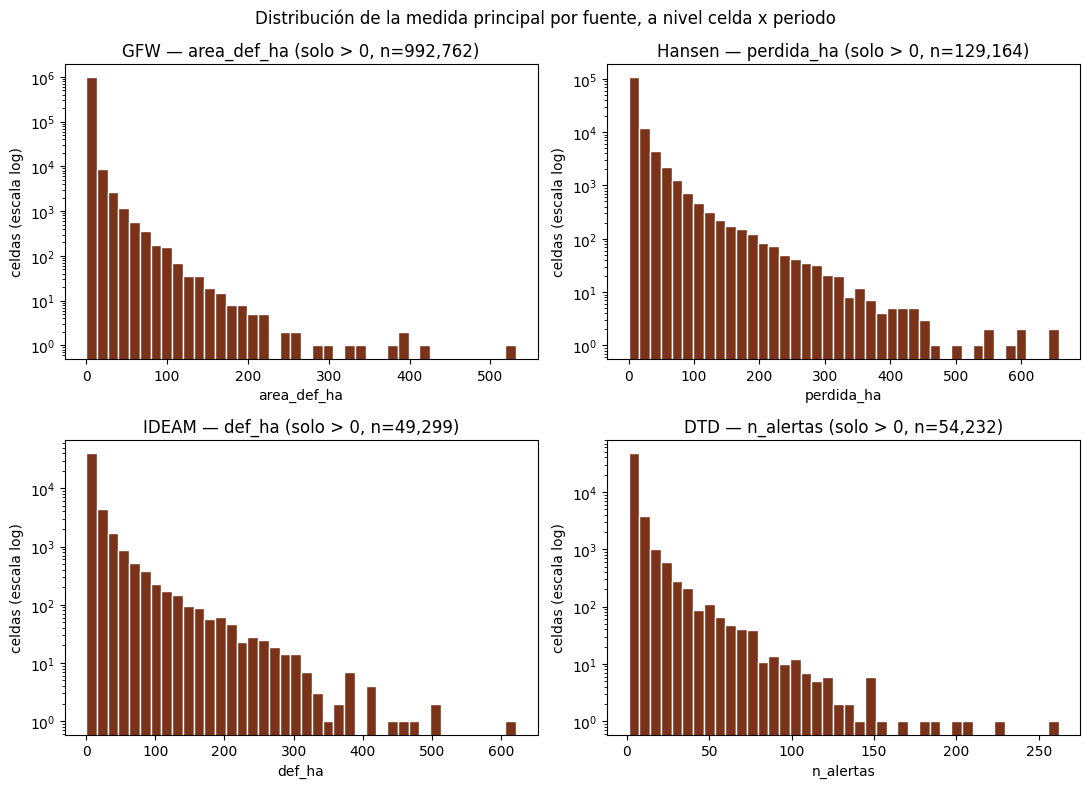

In [16]:
import matplotlib.pyplot as plt

# Histograma de los valores DISTINTOS DE CERO: con tantos ceros (celdas sin
# evento ese periodo) un histograma normal se ve como una sola barra. Lo que
# interesa aqui es la forma de la distribucion CUANDO SI hay evento -- y para
# eso ayuda el eje Y en escala log, porque se espera cola larga (pocas celdas
# con mucha area/perdida/alertas, muchas con poca).
fig, ejes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (fuente, (tabla, col)) in zip(ejes.flat, MEDIDA.items()):
    valores = tabla.loc[tabla[col] > 0, col]
    ax.hist(valores, bins=40, color="#7A3319", edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(f"{fuente} — {col} (solo > 0, n={len(valores):,})")
    ax.set_xlabel(col)
    ax.set_ylabel("celdas (escala log)")
fig.suptitle("Distribución de la medida principal por fuente, a nivel celda x periodo")
fig.tight_layout()

### Agregado por municipio

La misma medida, pero sumada por `cod_dane` a lo largo de toda la ventana
temporal: muestra qué tan concentrada está la señal en pocos municipios
frente a estar repartida de forma pareja -- relevante para el KPI que pidió
el tutor de cruzar desforestación con otras variables a nivel municipal.

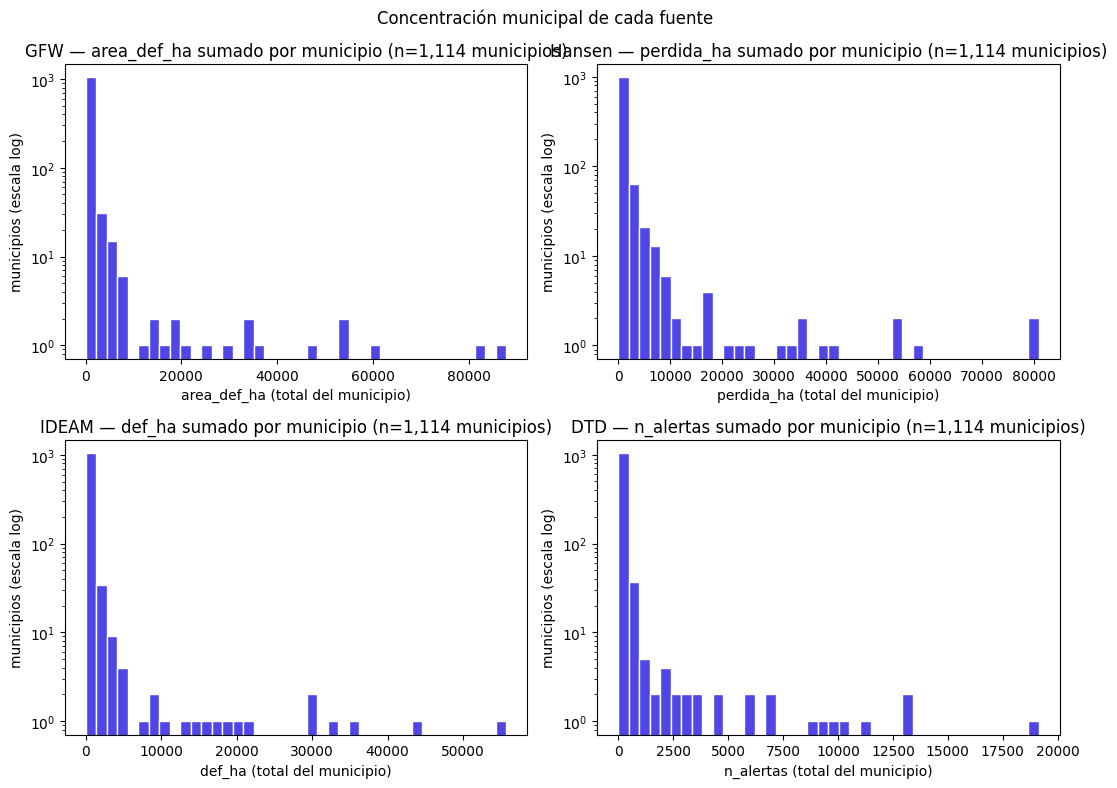

In [17]:
fig, ejes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (fuente, (tabla, col)) in zip(ejes.flat, MEDIDA.items()):
    por_municipio = tabla.groupby("cod_dane")[col].sum()
    ax.hist(por_municipio, bins=40, color="#4F46E5", edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(f"{fuente} — {col} sumado por municipio (n={por_municipio.shape[0]:,} municipios)")
    ax.set_xlabel(f"{col} (total del municipio)")
    ax.set_ylabel("municipios (escala log)")
fig.suptitle("Concentración municipal de cada fuente")
fig.tight_layout()

### Dispersión por departamento (fuente oficial IDEAM)

Boxplot de `def_ha` sumado por municipio, agrupado por departamento, para
los departamentos con mayor deforestación acumulada. Un boxplot muestra de
un vistazo la mediana, el rango intercuartílico y los municipios atípicos
dentro de cada departamento -- útil para decidir si algún outlier amerita
revisión manual antes del cruce.

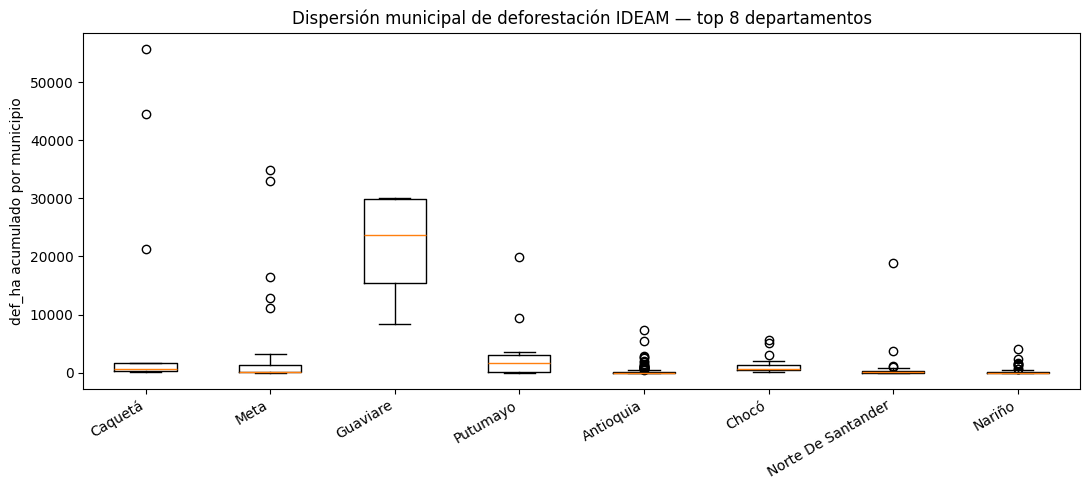

In [18]:
TOP_DEPTOS = 8

por_muni_dpto = (ideam.groupby(["cod_dane", "departamento"]).def_ha.sum()
                       .reset_index())
orden = (por_muni_dpto.groupby("departamento").def_ha.sum()
                       .sort_values(ascending=False).head(TOP_DEPTOS).index)

datos_boxplot = [por_muni_dpto.loc[por_muni_dpto.departamento == d, "def_ha"]
                  for d in orden]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(datos_boxplot, tick_labels=orden, showfliers=True)
ax.set_ylabel("def_ha acumulado por municipio")
ax.set_title(f"Dispersión municipal de deforestación IDEAM — top {TOP_DEPTOS} departamentos")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()

### Hallazgos

- **% de ceros por fuente:** GFW 71.8%, Hansen 51.7%, IDEAM 77.9%, DTD 95.1%.
  Es consistente con lo esperado para un panel de alertas (la mayoria de
  celda-periodo sin evento) -- DTD es la mas dispersa y probablemente conviene
  mirarla siempre agregada (por municipio o periodo), no a nivel celda.
- **Sesgo / outliers:** las cuatro distribuciones son fuertemente sesgadas a
  la derecha. A nivel departamental, Guaviare tiene una caja alta y compacta
  (deforestacion consistentemente alta), mientras que Caqueta y Meta tienen
  municipios outlier extremos (Cartagena del Chaira ~55,725 ha, San Vicente
  del Caguan ~44,512 ha acumuladas). Otros departamentos tienen outliers
  puntuales, no generalizados.
- **¿Se necesita limpieza?** No se encontro evidencia de errores de datos --
  el sesgo es una caracteristica real del fenomeno (la deforestacion se
  concentra en pocos municipios/celdas), no un problema de calidad. La
  implicacion es para el modelado (zero-inflation, transformacion log), no
  para limpieza de los datos.


---

## 6. Llave municipal: compatibilidad con las tablas del Observatorio

El profesor Jairo autorizo el 14/09/2026 acceso de solo lectura a tres tablas
del Observatorio (proyecto `prueba-ofr`): `FINAGRO_Desembolsos_EFECTIVA`,
`SFC414_DASH` y `Municipios.CODIGO`. Se describieron con
`describir_fuentes_profesor.py` (cuenta personal de Google via ADC, mientras
el profesor autoriza tambien a la cuenta de servicio) -- ver
`DESCRIPCION_FUENTES_PROFESOR.md` para columnas y muestra completas de cada
una.

| Tabla | Filas | Columnas | Columna de municipio |
|---|---|---|---|
| `FINAGRO_Desembolsos_EFECTIVA` | 6,158,859 | 37 | `cod_municipio` (STRING) |
| `SFC414_DASH` | 1,948,973 | 17 | `Codigo_Municipio` (STRING) |
| `Municipios.CODIGO` | 20,196 | 6 | `cod_dane` (STRING) |

Antes de cruzar esas tablas con nuestro panel habia que resolver uno de los
pendientes del tutor: confirmar si la llave municipal (`cod_dane`) es
compatible entre ambos lados. Las tres tablas del profesor guardan el codigo
de municipio como **STRING, con el cero a la izquierda conservado**
(`"05001"` para Medellin). En nuestro panel, `cargar()` (celda de arriba del
todo) ya declara `cod_dane` como texto al leer el CSV por la misma razon --
pero la tabla equivalente subida a BigQuery (`staging.stg_*`, ver
`DESCRIPCION_FUENTES.md`) quedo como **INTEGER**, que pierde ese cero. Es
decir: en pandas (este notebook) el cruce ya es seguro; un cruce hecho
directamente en BigQuery entre `staging.*` y las tablas del profesor
necesitaria primero convertir `cod_dane` a texto de 5 caracteres con
`LPAD(CAST(cod_dane AS STRING), 5, '0')`.

La celda de abajo lo verifica con datos reales: cuenta cuantos municipios de
nuestro panel tienen match, como texto, con el catalogo `Municipios.CODIGO`
del profesor.


In [19]:
# Requiere credenciales personales via ADC (ver GUIA_CODIGO.md, seccion
# 5.17b / describir_fuentes_profesor.py):
#     gcloud auth application-default login
# (una sola vez por maquina, con la cuenta de Google que autorizo el profesor)
import google.auth
from google.cloud import bigquery

try:
    credenciales, _ = google.auth.default(
        scopes=["https://www.googleapis.com/auth/bigquery"])
    client = bigquery.Client(project="ofr-credito-deforestacion", credentials=credenciales)

    municipios_profe = client.query(
        "SELECT DISTINCT cod_dane FROM `prueba-ofr.Municipios.CODIGO`"
    ).result().to_dataframe()["cod_dane"]

    propios = set(ideam["cod_dane"].unique())
    ajenos = set(municipios_profe)

    print(f"Municipios propios (panel IDEAM):                {len(propios)}")
    print(f"Municipios en Municipios.CODIGO del profesor:    {len(ajenos)}")
    print(f"En comun (cruzando como texto, cero a la izq.):  {len(propios & ajenos)}")
    print(f"Propios sin match en la tabla del profesor:      {len(propios - ajenos)}")
    if propios - ajenos:
        print("Ejemplos sin match:", sorted(propios - ajenos)[:10])
except Exception as e:
    print("No se pudo consultar BigQuery con la cuenta personal (¿falta "
          "correr 'gcloud auth application-default login'?). Detalle:", e)


20:30:47 | WARNING | No project ID could be determined. Consider running `gcloud config set project` or setting the GOOGLE_CLOUD_PROJECT environment variable


Municipios propios (panel IDEAM):                1114
Municipios en Municipios.CODIGO del profesor:    1122
En comun (cruzando como texto, cero a la izq.):  1113
Propios sin match en la tabla del profesor:      1
Ejemplos sin match: ['27493']


### Hallazgos

- **Match casi total:** de los 1,114 municipios de nuestro panel, **1,113
  (99.9%)** cruzan sin problema con el catalogo `Municipios.CODIGO` del
  profesor al tratar `cod_dane` como texto de 5 caracteres. Esto confirma
  que el formato (INTEGER vs. STRING / cero a la izquierda) era el unico
  riesgo real, y que ya esta resuelto en pandas gracias a `cargar()`.
- **Unico caso sin match:** `cod_dane = 27493` (departamento del Choco, 27xxx)
  no aparece en el catalogo del profesor -- no es un caso de perdida del cero
  a la izquierda (el codigo no empieza en 0), asi que hay que revisarlo aparte
  (¿division/creacion reciente de municipio, o un codigo distinto para el
  mismo territorio en la fuente del profesor?) antes de asumir que es un
  error de nuestros datos.
- **¿Se necesita normalizar antes del cruce con FINAGRO/SFC414?** Si, pero
  solo al cruzar directamente en BigQuery (`staging.*` quedo como INTEGER
  ahi) -- en pandas, siempre y cuando se siga usando `cargar()` (que ya
  declara `cod_dane` como texto), el cruce con las tablas del profesor es
  seguro tal cual.


---

## 7. Correlación entre fuentes de deforestación

Punto 6 de la lista del tutor y foco de la semana 8 del cronograma: cuantificar
qué tanto coinciden las cuatro fuentes entre sí, en vez de solo mirarlas por
separado (secciones anteriores) o comparar cifras nacionales año a año sin
un número que resuma el acuerdo. Se mira desde dos ángulos, porque las
fuentes miden cosas distintas y a distinta granularidad temporal (celda 1,
arriba: GFW es mensual, Hansen es anual, IDEAM es bienal, DTD es trimestral):

1. **En el tiempo** (nivel nacional): ¿suben y bajan juntas, año a año? Se
   agregan las cuatro a año calendario (IDEAM se asigna al año en que
   termina su periodo bienal, igual que en "Cifras nacionales por año").
2. **En el espacio** (nivel municipio): ¿los municipios que una fuente marca
   como más deforestados son los mismos que marcan las demás? Se usa el
   total acumulado de cada fuente por `cod_dane` en toda la ventana
   (2020-2026), el mismo agregado de "Agregado por municipio" más arriba.

En ambos casos se reporta **Pearson** (correlación lineal, sensible a la
magnitud) y **Spearman** (correlación de rangos): dado el fuerte sesgo a la
derecha que ya se encontró en el EDA visual (Hallazgos de esa sección),
Spearman es la medida más confiable acá -- le importa el orden relativo, no
la magnitud, y no lo distorsionan los outliers extremos (Cartagena del
Chairá, San Vicente del Caguán).

In [20]:
# Cifras nacionales por año, las cuatro fuentes juntas. NaN = ese año
# no existe (o no esta completo) en esa fuente -- no se rellena con 0
# porque "sin dato" y "cero deforestacion" son cosas distintas.
anual_4f = pd.DataFrame({
    "GFW":    gfw.groupby("anio").area_def_ha.sum(),
    "Hansen": hansen.groupby("anio").perdida_ha.sum(),
    "IDEAM":  (ideam.assign(anio=ideam.periodo.str[-4:].astype(int))
                     .groupby("anio").def_ha.sum()),
    "DTD":    dtd.groupby("anio").n_alertas.sum(),
})
anual_4f.round(0)

,GFW,Hansen,IDEAM,DTD
anio,,,,
2020,219394.0,324608.0,NaN,21895
2021,194710.0,265200.0,173663.0,15065
2022,170286.0,266168.0,123204.0,27579
2023,123973.0,197246.0,78982.0,31923
2024,155220.0,213785.0,113423.0,45754
2025,144577.0,186697.0,119282.0,51072
2026,80608.0,NaN,NaN,28990


In [21]:
# La correlacion solo tiene sentido en los anios donde las cuatro
# fuentes tienen dato -- normalmente excluye 2020 (IDEAM arranca en el
# periodo 2020-2021, que se cuenta como 2021) y el anio en curso (2026,
# parcial: ver fecha_fin en config_local.py).
comun = anual_4f.dropna()
print(f"Anios con dato en las cuatro fuentes: {list(comun.index.astype(int))}")
print()
print("Correlacion de Pearson (nivel):")
print(comun.corr(method="pearson").round(2).to_string())
print()
print("Correlacion de Spearman (rangos -- mas robusta al sesgo):")
print(comun.corr(method="spearman").round(2).to_string())

Anios con dato en las cuatro fuentes: [2021, 2022, 2023, 2024, 2025]

Correlacion de Pearson (nivel):
         GFW  Hansen  IDEAM   DTD
GFW     1.00    0.86   0.95 -0.63
Hansen  0.86    1.00   0.69 -0.81
IDEAM   0.95    0.69   1.00 -0.53
DTD    -0.63   -0.81  -0.53  1.00

Correlacion de Spearman (rangos -- mas robusta al sesgo):
        GFW  Hansen  IDEAM  DTD
GFW     1.0     0.8    0.9 -0.7
Hansen  0.8     1.0    0.6 -0.8
IDEAM   0.9     0.6    1.0 -0.6
DTD    -0.7    -0.8   -0.6  1.0


### Agregado por municipio (todo el periodo)

Mismo total por `cod_dane` que en "Agregado por municipio" más arriba
(`MEDIDA`, definido en esa sección), reutilizado aquí para la correlación
espacial: si dos fuentes están de acuerdo, los municipios con el total más
alto en una deberían ser, en general, los mismos en la otra.

In [22]:
por_municipio_4f = pd.DataFrame({
    fuente: tabla.groupby("cod_dane")[col].sum()
    for fuente, (tabla, col) in MEDIDA.items()
})
print(f"Municipios: {len(por_municipio_4f):,}")
print()
print("Correlacion de Pearson (nivel):")
print(por_municipio_4f.corr(method="pearson").round(2).to_string())
print()
print("Correlacion de Spearman (rangos):")
print(por_municipio_4f.corr(method="spearman").round(2).to_string())

Municipios: 1,114

Correlacion de Pearson (nivel):
         GFW  Hansen  IDEAM   DTD
GFW     1.00    0.98   0.99  0.96
Hansen  0.98    1.00   0.98  0.96
IDEAM   0.99    0.98   1.00  0.97
DTD     0.96    0.96   0.97  1.00

Correlacion de Spearman (rangos):
         GFW  Hansen  IDEAM   DTD
GFW     1.00    0.79   0.79  0.74
Hansen  0.79    1.00   0.80  0.75
IDEAM   0.79    0.80   1.00  0.81
DTD     0.74    0.75   0.81  1.00


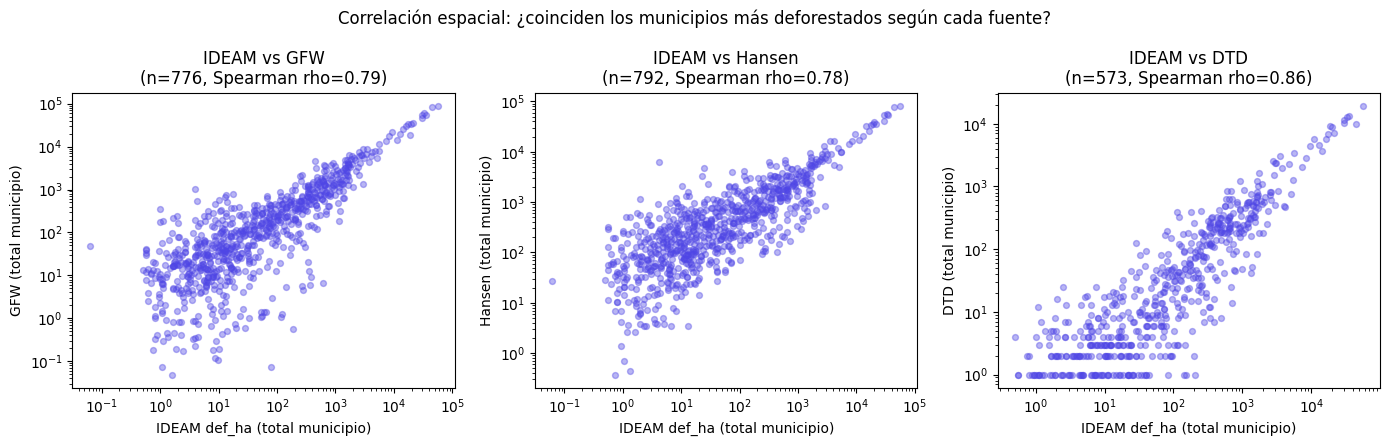

In [23]:
from scipy.stats import spearmanr

# Escala log en los dos ejes, porque ya se establecio (seccion de EDA
# visual) que las cuatro distribuciones estan fuertemente sesgadas --
# en escala lineal los outliers aplastarian el resto de los puntos.
# Solo entran municipios con actividad en ambas fuentes del par (>0):
# un municipio en cero en una de las dos no aporta nada en log-log.
fig, ejes = plt.subplots(1, 3, figsize=(14, 4.5))
otras = [f for f in MEDIDA if f != "IDEAM"]
for ax, fuente in zip(ejes, otras):
    x = por_municipio_4f["IDEAM"]
    y = por_municipio_4f[fuente]
    m = (x > 0) & (y > 0)
    rho, _ = spearmanr(x[m], y[m])
    ax.scatter(x[m], y[m], alpha=0.4, s=18, color="#4F46E5")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("IDEAM def_ha (total municipio)")
    ax.set_ylabel(f"{fuente} (total municipio)")
    ax.set_title(f"IDEAM vs {fuente}\n(n={m.sum()}, Spearman rho={rho:.2f})")
fig.suptitle("Correlación espacial: ¿coinciden los municipios más deforestados según cada fuente?")
fig.tight_layout()

### Hallazgos

- **En el tiempo (nacional, 2021-2025 -- los cinco años con dato en las
  cuatro fuentes; se excluyen 2020, sin IDEAM, y 2026, parcial): GFW,
  Hansen e IDEAM concuerdan razonablemente bien entre sí** (Pearson
  0.69-0.95, Spearman 0.6-0.9) -- las tres bajan desde un pico en 2021
  hasta un mínimo en 2023, con un repunte parcial después. **DTD va en
  sentido contrario**: su correlación con las otras tres es NEGATIVA
  (Pearson entre -0.53 y -0.81; Spearman entre -0.6 y -0.8), porque el
  número de detecciones tempranas *sube* de 2021 a 2025 mientras las
  hectáreas de las otras tres *bajan*. La lectura más probable no es que
  la deforestación esté realmente aumentando según DTD, sino que DTD
  cuenta puntos de alerta (no hectáreas) y es sensible al esfuerzo de
  monitoreo del SMByC, que parece haber crecido en esos años -- por eso
  su tendencia temporal no debería leerse al pie de la letra como una
  señal de deforestación.
- **En el espacio (1,114 municipios, toda la ventana 2020-2026): las
  cuatro fuentes coinciden fuertemente en QUÉ municipios son los más
  deforestados**, incluyendo DTD -- Pearson 0.96-0.99 (inflado por los
  mismos outliers extremos de la sección de EDA visual, Cartagena del
  Chairá y San Vicente del Caguán, que dominan las cuatro fuentes por
  igual) y Spearman, más confiable acá, 0.74-0.81. Esto valida usar
  cualquiera de las cuatro (o una combinación) para el tamizaje de riesgo
  municipal, que es el uso previsto del cruce con las variables
  financieras.
- **Implicación para el modelado:** DTD es confiable para el corte
  espacial (qué municipios) pero no para el corte temporal (qué años) sin
  ajustar por el esfuerzo de monitoreo -- conviene no usarlo tal cual como
  serie de tiempo de deforestación sin controlar por año (p. ej., con
  efectos fijos de año), aunque sí sirve para el ranking de riesgo por
  municipio junto con las otras tres.

---

## 8. Calidad de datos: faltantes, duplicados y outliers

Punto 5 de la lista del tutor, semanas 9-10 del cronograma. Los outliers ya
se documentaron de forma visual/cualitativa en la sección de EDA visual
(Hallazgos, arriba); esta sección completa el reporte formal con tres
verificaciones sistemáticas sobre las cuatro fuentes:

1. **Faltantes** -- distinguiendo los que son estructurales por diseño (por
   ejemplo, las columnas de rezago de GFW no pueden existir en los primeros
   periodos de cada celda) de un hueco real e inesperado en los datos.
2. **Duplicados** -- filas exactamente repetidas, y duplicados de la llave
   `cell_id` + periodo/año (que invalidarían cualquier `.sum()` o `.groupby()`
   ya usado en este cuaderno, incluidas las correlaciones de la sección 7).
3. **Outliers, con una regla estadística explícita** -- percentil 99 entre
   las celda-periodo *con evento* de cada fuente (no sobre el total, que es
   mayormente ceros -- ver % de ceros en la sección de EDA visual), y si esos
   outliers se concentran en los mismos municipios ya identificados
   (Cartagena del Chairá, San Vicente del Caguán).

### 8.1 Faltantes

In [51]:
FUENTES_DF = {"GFW": gfw, "Hansen": hansen, "IDEAM": ideam, "DTD": dtd}

faltantes = []
for fuente, tabla in FUENTES_DF.items():
    nulos = tabla.isna().sum()
    nulos = nulos[nulos > 0]
    for col, n in nulos.items():
        faltantes.append({
            "fuente": fuente, "columna": col,
            "faltantes": n, "% del total": round(100 * n / len(tabla), 3),
        })

if faltantes:
    print("Columnas con al menos un faltante (las que no aparecen aqui tienen 0):\n")
    print(pd.DataFrame(faltantes).set_index(["fuente", "columna"]).to_string())
else:
    print("Ninguna columna de ninguna fuente tiene faltantes.")

Columnas con al menos un faltante (las que no aparecen aqui tienen 0):

                        faltantes  % del total
fuente columna                                
GFW    lag_1_ha             44616        1.266
       lag_2_ha             89232        2.532
       lag_3_ha            133848        3.797
       media_movil_3       133848        3.797
DTD    n_alertas_sinap     312312       28.000


In [54]:
# GFW tiene columnas de rezago (lag_1_ha, lag_2_ha, lag_3_ha, media_movil_3):
# por construccion, las primeras 1, 2 y 3 celda-mes de cada celda no tienen
# historia suficiente para calcularlas -- eso es un faltante ESTRUCTURAL, no
# un hueco real. Se verifica contando cuantas celdas hay y comparando contra
# el conteo esperado (n_celdas x posicion del rezago).
n_celdas = gfw.cell_id.nunique()
for col, rezago in [("lag_1_ha", 1), ("lag_2_ha", 2), ("lag_3_ha", 3)]:
    esperado = n_celdas * rezago
    real = gfw[col].isna().sum()
    print(f"{col:<14} faltantes reales: {real:>7,}   esperados (n_celdas x {rezago}): {esperado:>7,}   "
          f"coincide: {real == esperado}")

lag_1_ha       faltantes reales:  44,616   esperados (n_celdas x 1):  44,616   coincide: True
lag_2_ha       faltantes reales:  89,232   esperados (n_celdas x 2):  89,232   coincide: True
lag_3_ha       faltantes reales: 133,848   esperados (n_celdas x 3): 133,848   coincide: True


### 8.2 Duplicados

In [55]:
# cell_id + periodo (o anio, para Hansen) deberia ser una llave unica en
# las cuatro fuentes -- si no lo es, cualquier .sum()/.groupby() ya hecho en
# este cuaderno (incluidas las correlaciones de la seccion 7) estaria
# contando filas de mas.
llave_periodo = {"GFW": "periodo", "Hansen": "anio", "IDEAM": "periodo", "DTD": "periodo"}

for fuente, tabla in FUENTES_DF.items():
    col = llave_periodo[fuente]
    dup_exactas = tabla.duplicated().sum()
    dup_llave = tabla.duplicated(subset=["cell_id", col]).sum()
    print(f"{fuente:<8} filas: {len(tabla):>9,}   duplicadas exactas: {dup_exactas:>4}   "
          f"duplicadas de llave (cell_id + {col}): {dup_llave:>4}")

GFW      filas: 3,524,664   duplicadas exactas:    0   duplicadas de llave (cell_id + periodo):    0
Hansen   filas:   267,696   duplicadas exactas:    0   duplicadas de llave (cell_id + anio):    0
IDEAM    filas:   223,080   duplicadas exactas:    0   duplicadas de llave (cell_id + periodo):    0
DTD      filas: 1,115,400   duplicadas exactas:    0   duplicadas de llave (cell_id + periodo):    0


### 8.3 Outliers -- regla estadística explícita

In [56]:
# Se define outlier como: celda-periodo CON evento (>0) que supera el
# percentil 99 de esa misma fuente, calculado solo entre las celda-periodo
# con evento -- calcularlo sobre el total no serviria (el total es
# mayormente ceros, ver % de ceros en la seccion de EDA visual, asi que el
# p99 del total seguiria siendo cero o casi cero).
print("Outliers por fuente (p99 calculado solo entre celda-periodo con evento):\n")
for fuente, (tabla, col) in MEDIDA.items():
    con_evento = tabla[tabla[col] > 0]
    p99 = con_evento[col].quantile(0.99)
    outliers = con_evento[con_evento[col] > p99]
    top_municipios = (outliers.groupby("municipio")[col].sum()
                              .sort_values(ascending=False).head(3))
    print(f"{fuente:<8} p99 (con evento) = {p99:>12,.2f} {col:<16} "
          f"outliers: {len(outliers):>5} ({100 * len(outliers) / len(con_evento):.2f}% de las celda-periodo con evento)")
    print("          concentrados en:",
          ", ".join(f"{m} ({v:,.0f})" for m, v in top_municipios.items()))
    print()

Outliers por fuente (p99 calculado solo entre celda-periodo con evento):

GFW      p99 (con evento) =        17.19 area_def_ha      outliers:  9928 (1.00% de las celda-periodo con evento)
          concentrados en: Cartagena Del Chairá (54,276), San Vicente Del Caguán (46,639), La Macarena (34,069)

Hansen   p99 (con evento) =       119.75 perdida_ha       outliers:  1291 (1.00% de las celda-periodo con evento)
          concentrados en: San Vicente Del Caguán (35,201), Cartagena Del Chairá (34,134), La Macarena (24,103)

IDEAM    p99 (con evento) =       140.88 def_ha           outliers:   493 (1.00% de las celda-periodo con evento)
          concentrados en: Cartagena Del Chairá (23,242), San Vicente Del Caguán (16,002), Calamar (11,965)

DTD      p99 (con evento) =        38.00 n_alertas        outliers:   519 (0.96% de las celda-periodo con evento)
          concentrados en: Cartagena Del Chairá (7,604), Calamar (3,920), La Macarena (3,716)



### Hallazgos

- **Faltantes: todos estructurales, ninguno es un hueco real.** Los únicos
  NaN son las columnas de rezago de GFW (`lag_1_ha` 1.27%, `lag_2_ha`
  2.53%, `lag_3_ha`/`media_movil_3` 3.80%) -- confirmado exacto contra el
  conteo esperado (n_celdas × posición del rezago, coincide: True en los
  tres) -- y `n_alertas_sinap` de DTD (28.0%), que ya se sabía que el
  SMByC no reporta en todos los trimestres (sección "Detecciones por
  año", arriba: 18 de 25 trimestres con dato). `cod_dane`, `municipio` y
  `departamento` no tienen ningún faltante en ninguna de las cuatro
  fuentes -- el cruce municipal (`asignar_municipio()`) asignó el 100%
  de las celdas.
- **Duplicados: cero, en las cuatro fuentes.** Ni filas exactamente
  repetidas ni duplicados de la llave `cell_id` + periodo/año. Esto
  confirma que las agregaciones (`.sum()`, `.groupby()`) usadas en todo
  el cuaderno -- incluidas las correlaciones de la sección 7 -- no están
  contando ninguna fila de más.
- **Outliers: ~1% de las celda-periodo con evento en cada fuente (por
  definición del p99), pero concentrados de forma consistente en el
  mismo puñado de municipios en las CUATRO fuentes de forma
  independiente.** Cartagena del Chairá y San Vicente del Caguán
  (Caquetá) encabezan en GFW, Hansen e IDEAM; La Macarena (Meta)
  aparece en GFW, Hansen y DTD; Calamar (Guaviare) aparece en IDEAM y
  DTD. Que cuatro mediciones independientes -- con distintos sensores,
  unidades y metodología -- coincidan en los mismos municipios extremos
  es evidencia fuerte de que es un fenómeno real (el "arco de
  deforestación" de la Amazonía colombiana), no un error de datos.
  Confirma la conclusión de la sección de EDA visual: el sesgo no
  requiere limpieza, es una característica genuina de dónde se
  concentra la deforestación.